# BUSINESS DATA ANALYTICS APPLIED LAB 2: RISK MANAGEMENT & OSH ANALYTICS
Un conglomerado de 150 empresas está alarmado por el aumento en los reportes de accidentes laborales. El costo de las incapacidades y el impacto humano están afectando la productividad global. La gerencia no solo necesita saber cuántos accidentes ocurren, sino que requiere identificar patrones de riesgo para implementar una estrategia de prevención. Su misión como analista de datos consiste en aplicar la metodología CRISP-DM para consolidar fuentes de datos dispersas, generar evidencia visual sobre los factores de riesgo (jornada, capacitación y sector) y proponer reglas de negocio preventivas.

_Actualizado: 16/02/2026_
_ebuitragob@ucentral.edu.co_

## Carga y transformación datos

In [ ]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Paso 1: Carga y Preparación de Datos (Data Understanding)
df_trabajadores = pd.read_csv('trabajadores.csv')
df_empresas = pd.read_csv('empresas.csv')
df_accidentes = pd.read_csv('accidentes.csv')


In [ ]:
# Paso 2: Consolidación de Información (Data Preparation / Triple Join)
# Unimos trabajadores con empresas
df_merge = pd.merge(df_trabajadores, df_empresas, left_on='empresa', right_on='id_empresa')

# Unir con accidentes (Left join para no perder a quienes NO tuvieron accidentes)
df_final = pd.merge(df_merge, df_accidentes, on='id_trabajador', how='left')

# Crear variable binaria: 1 si hubo accidente, 0 si no
df_final['incidente'] = df_final['id_accidente'].notnull().astype(int)

## Visualización

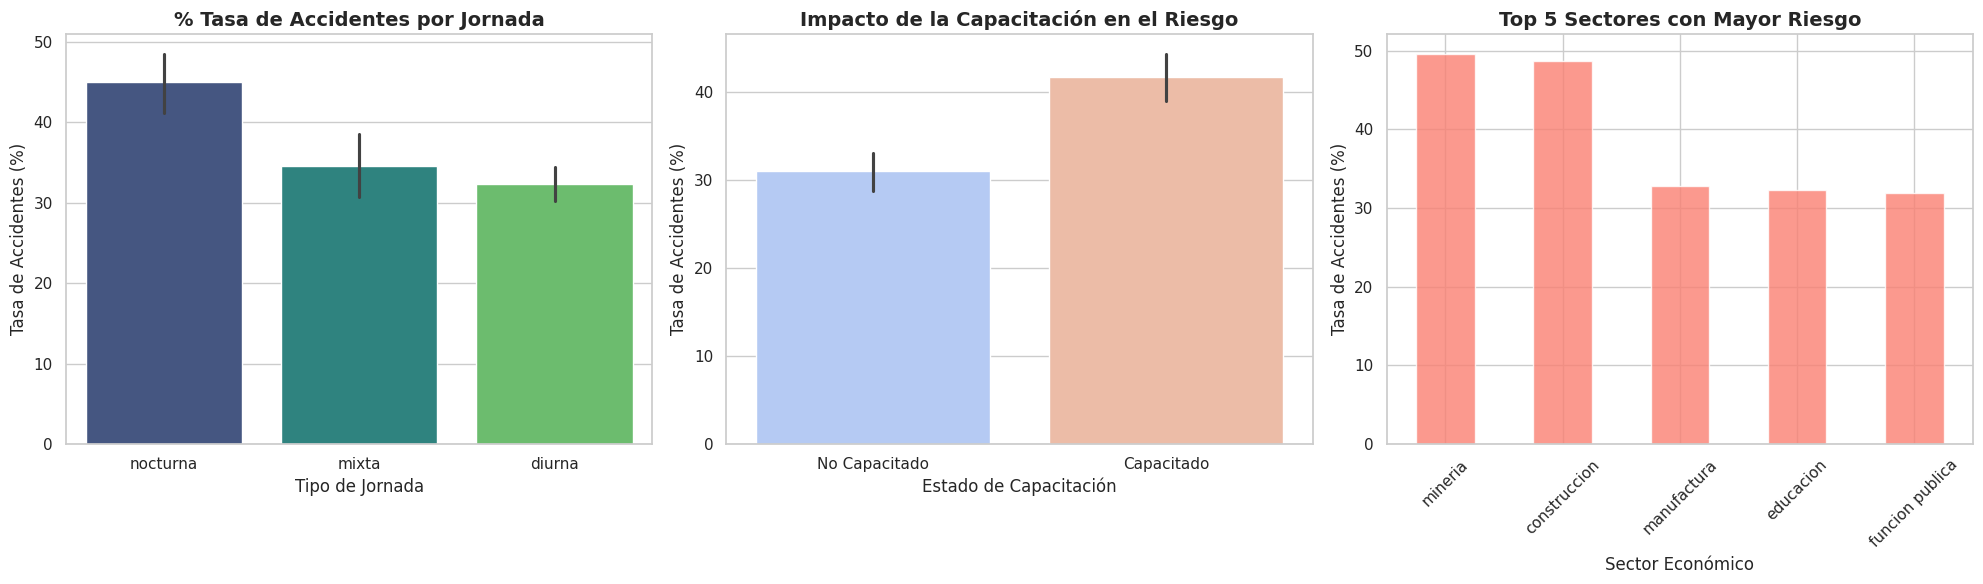

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo base
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 6))

# Gráfico 1: Riesgo por Jornada
plt.subplot(1, 3, 1)
ax1 = sns.barplot(data=df_final, x='jornada', y='incidente', estimator=lambda x: sum(x)/len(x)*100, palette='viridis', hue='jornada', legend=False)
plt.title('% Tasa de Accidentes por Jornada', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Jornada', fontsize=12)
plt.ylabel('Tasa de Accidentes (%)', fontsize=12)

# Gráfico 2: Impacto de la Capacitación
plt.subplot(1, 3, 2)
ax2 = sns.barplot(data=df_final, x='capacitado', y='incidente', estimator=lambda x: sum(x)/len(x)*100, palette='coolwarm', hue='capacitado', legend=False)
plt.xticks([0, 1], ['No Capacitado', 'Capacitado'])
plt.title('Impacto de la Capacitación en el Riesgo', fontsize=14, fontweight='bold')
plt.xlabel('Estado de Capacitación', fontsize=12)
plt.ylabel('Tasa de Accidentes (%)', fontsize=12)

# Gráfico 3: Sectores más críticos (Top 5)
plt.subplot(1, 3, 3)
top_5_sectores = df_final.groupby('sector_economico')['incidente'].mean().sort_values(ascending=False).head(5) * 100
top_5_sectores.plot(kind='bar', color='salmon', alpha=0.8)
plt.title('Top 5 Sectores con Mayor Riesgo', fontsize=14, fontweight='bold')
plt.xlabel('Sector Económico', fontsize=12)
plt.ylabel('Tasa de Accidentes (%)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#  SECCIÓN DE EXPLORACIÓN AUTÓNOMA
 INSTRUCCIÓN: El estudiante debe generar otros gráficos que considere necesarios para profundizar en su análisis.

 Sugerencia: Explore la relación entre '`antiguedad`', '`nivel_educativo`' o '`sistema_gestion`' respecto a la variable '`incidente`'.

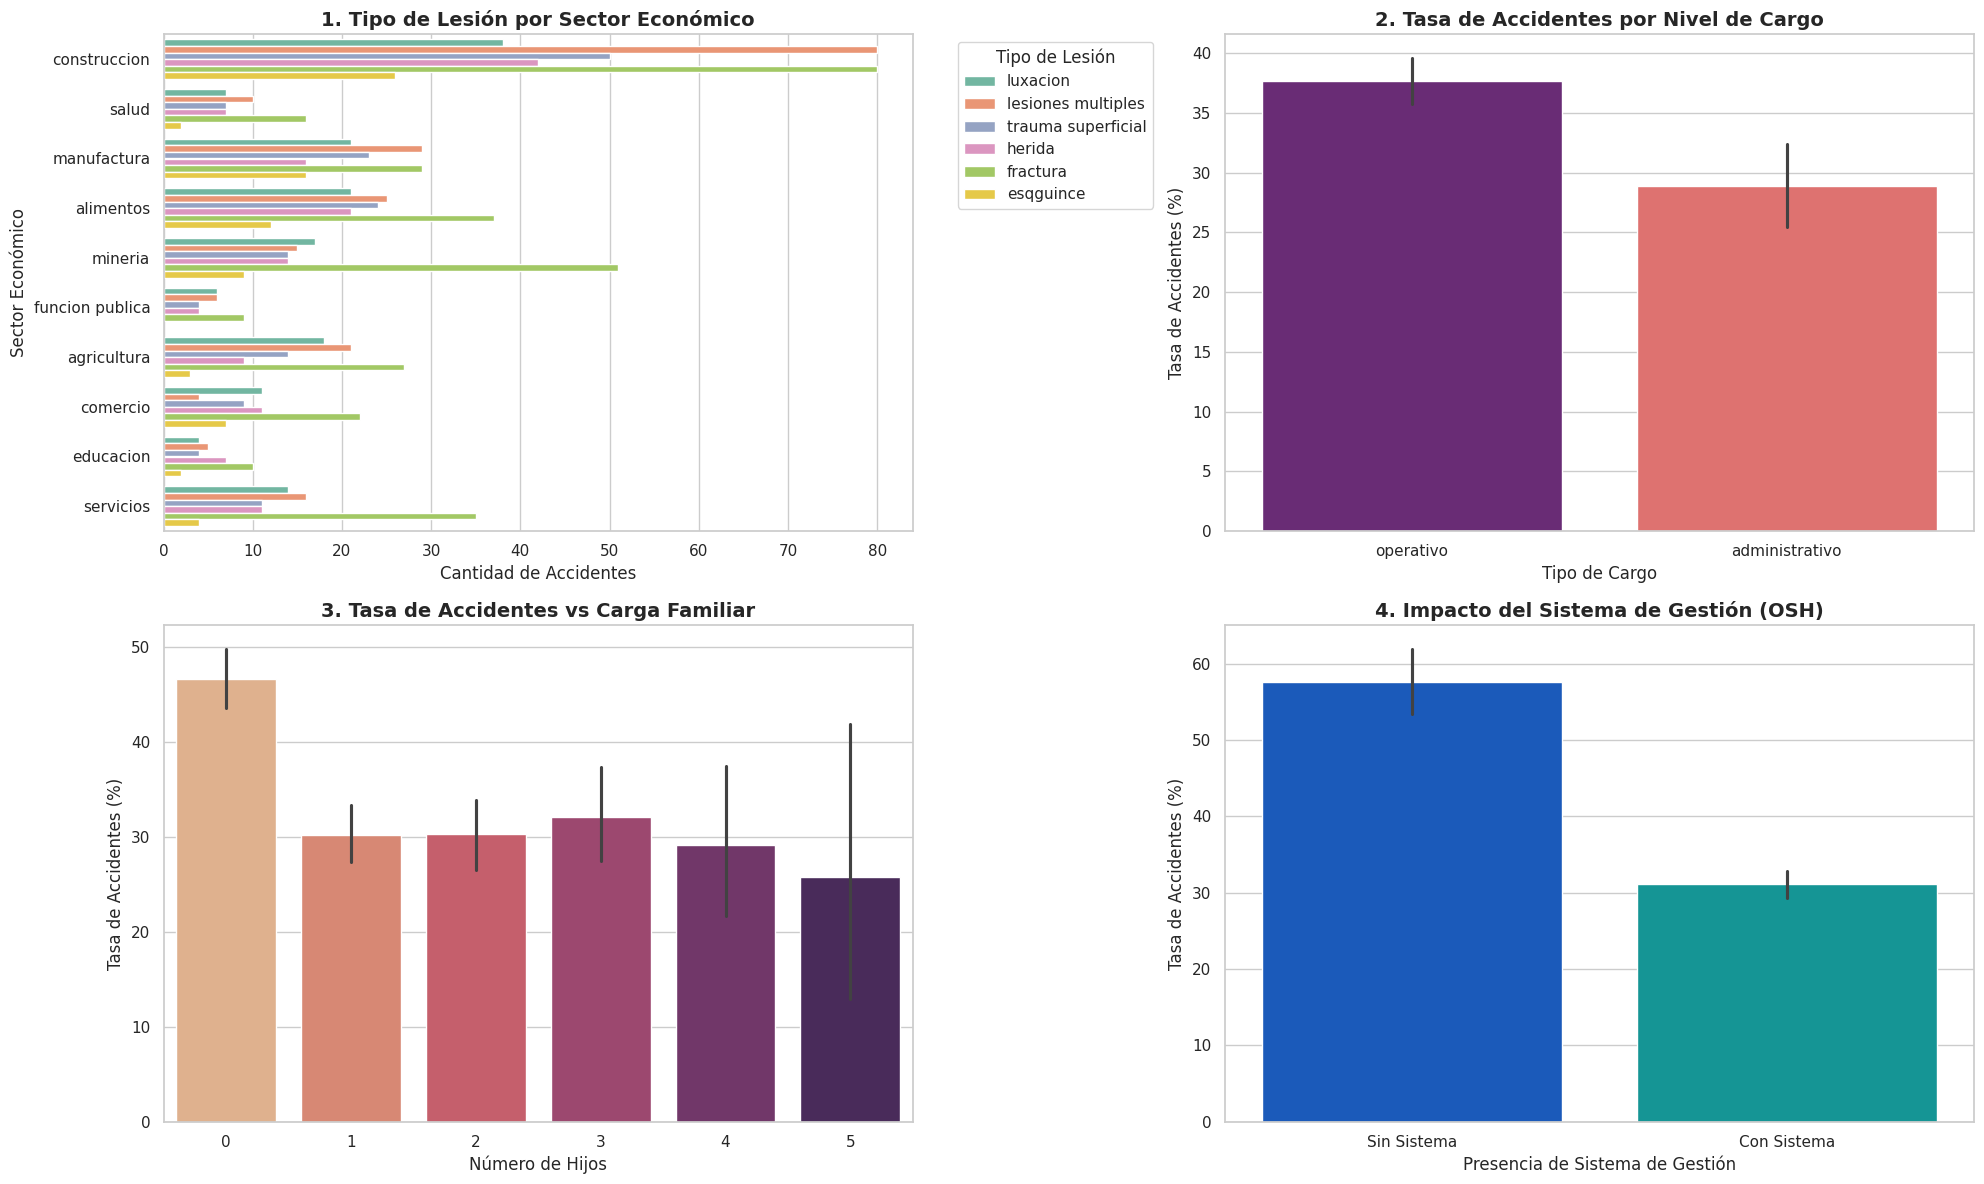

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 12))

# 1. Lesiones más frecuentes por sector
plt.subplot(2, 2, 1)
df_acc = df_final[df_final['incidente'] == 1]
sns.countplot(data=df_acc, y='sector_economico', hue='lesion', palette='Set2')
plt.title('1. Tipo de Lesión por Sector Económico', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Accidentes', fontsize=12)
plt.ylabel('Sector Económico', fontsize=12)
plt.legend(title='Tipo de Lesión', bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. Accidentes por tipo de cargo
plt.subplot(2, 2, 2)
sns.barplot(data=df_final, x='tipo_cargo', y='incidente', estimator=lambda x: sum(x)/len(x)*100, palette='magma', hue='tipo_cargo', legend=False)
plt.title('2. Tasa de Accidentes por Nivel de Cargo', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Cargo', fontsize=12)
plt.ylabel('Tasa de Accidentes (%)', fontsize=12)

# 3. Accidentes por número de hijos
plt.subplot(2, 2, 3)
sns.barplot(data=df_final, x='num_hijos', y='incidente', estimator=lambda x: sum(x)/len(x)*100, palette='flare', hue='num_hijos', legend=False)
plt.title('3. Tasa de Accidentes vs Carga Familiar', fontsize=14, fontweight='bold')
plt.xlabel('Número de Hijos', fontsize=12)
plt.ylabel('Tasa de Accidentes (%)', fontsize=12)

# 4. Accidentes por sistema de gestión
plt.subplot(2, 2, 4)
sns.barplot(data=df_final, x='sistema_gestion', y='incidente', estimator=lambda x: sum(x)/len(x)*100, palette='winter', hue='sistema_gestion', legend=False)
plt.xticks([0, 1], ['Sin Sistema', 'Con Sistema'])
plt.title('4. Impacto del Sistema de Gestión (OSH)', fontsize=14, fontweight='bold')
plt.xlabel('Presencia de Sistema de Gestión', fontsize=12)
plt.ylabel('Tasa de Accidentes (%)', fontsize=12)

plt.tight_layout()
plt.show()

## Análisis

**El obejtivo del negocio**: el conglomerado de 150 personas busca reducir accidentes laborales para bajar cosotos de incapacidades y recuperar inactividad.

**Objetivo de nosostros**: Identificar los factores de riesgo que mas se asocian a la tasa de accidentes para logara un "traduccion" en reglas de negocio preventiva.

* grafica 1 (Tasa de accidentes X Tipo de jornada): el turno nocturno tiene 13 puntos mas de accidentes que el diurno, es una diferencia grande, es un patron de riesgo claro para el objetivo, priorizar controles nocturnos.

* grafica 2 (tasa de accidentes X capacitacion): los capacitados tiene mas accidentes que los que no, frente al contexto del negocio, esto no serviria como una regla de prevencion, es un patron que hay investigar.

* grafica 3 (tasa de accidentes X sector economico): mineria y construccion estan por encima del resto, con una brecha de 16 puntos, es util para saber donde concentar el presupuesto de prevencion a accideentes primero.

* grafica 4 (sector economico X cantidad de accidentes): construccion presenta el mayor volumen de accidentes, con salud y manufactura le siguen, pero no es le volumen lo que es mas relevnte sino la mezcla de tipo de lesion, lo cual seria relevante para diseñar el tipo de prevencion, no solo donde.

* grafica 5 (tasa de accidentes X tipo de cargo): la diferencia es moderada y esperable, quien trabjaben planta o campo se exponene mas que los que trabajan en oficonas, sirve como confrimacion pero es "irrelevante" para el objetivo.

* grafica 6 (tasa de accidentes X numero de hijos): No hay un patron en si logico en cuento al numero de hijos, posbiblemente del tener familia o no, pero no sirve para el objetivo.

+ grafica 7 (tasa de accidentes X presencia de sistema de gestion): es donde mas hay diferencia de todo el set de graficias, casi el doble de accidentes sin sistema de gestion, es lo mas importante, la mayor justificacion sobre implemetar sistema de gestion en las empresas.


### 3. Hallazgos Adicionales:
### Distribución de Lesiones por Sector Económico
- En la primera gráfica de distribución de lesiones por sector económico quienes realizan trabajos operativos de mano de obra pesada y alto riesgo, están exigidos a realizar un esfuerzo físico intensivo por ende son la construcción y la minería quienes registran mayor cantidad de accidentes resaltando las fracturas y las lesiones múltiples, ambas rondando 80 casos.

Minería predomina por presentar la lesión de fracturas mayor a los 50 casos superando los otros tipos de lesiones
Mientras que los que requieren menor esfuerzo físico se caracterizan por tener índice de accidentes más bajos en todos los tipos de lesión como lo son los trabajos de función pública y educación.

###Tasa de Accidentes por Nivel de Cargo
- Entre el personal operativo y el administrativo hay una diferencia porcentual de 9 puntos, Esta diferencia ocurre porque el personal operativo está expuesto continuamente a maquinaria pesada, fatiga física y entornos impredecibles, lo que eleva su tasa de accidentalidad al 37.5% frente al 28.5% del área administrativa.

###Tasa de Accidentes vs. Carga Familiar
- Se planteó una hipótesis en la que la carga familiar podría generar mayor cansancio, fatiga o distracción fuera del trabajo, sin embargo lo que nos demostró la gráfica es que de hecho es que Los empleados con 0 hijos tienen la tasa de accidentalidad más elevada con el 46%, mientras que tener 1 o más hijos funciona como un factor protector o de estabilización entre 25% - 32%.

- El número de hijos funciona como un indicador indirecto de la edad y la experiencia del trabajador. Tener cero hijos no es lo que provoca los accidentes, pero nos sirve como pista: los empleados sin hijos suelen ser los más jóvenes, con menos tiempo en la empresa y falta de autoretroalimentación, lo que los expone a mayor riesgo por falta de experiencia en el trabajo.

###Sistema de Gestión de Seguridad y Salud
El Sistema de Gestión de Seguridad es la medida preventiva más efectiva de todas. Según los datos, tener este sistema reduce los accidentes en un 45% (haciendo que la tasa de accidentes caiga del 57% al 31%). Esto demuestra que la seguridad es una inversión directa en la productividad de la empresa.


## Conclusiones
El sistema de gestion de de seguridad es la medida mas efectiva para la prevencion de accidentes laborales, capacitaciones o estudios externos no ayudan a prevencion de accidentes ya que no es tema principal la prevencion de riesgos.

El turno nocturno tiene mayor accidentalidad que los turnos mixtos o diurnos, ya que representa factores de cansancio externo, pero no es el unico, trabajos dobles, cansancio por falta de sueño y relaciones familiares/amorosas tambien pueden aportar a este factor de riesgo.

Los sectores que posseen mayor numero de trabajos operativos son aquellos con mayor tasa de accidentalidad, concordando con el analisis de trabajos operativos v.s administrativos, por lo que deberian ser los primeros en implementar la gestion de seguridad.